## Calculating Stock Returns

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [4]:
df = pd.read_csv("../data/fb_price.csv")

In [5]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400
1,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700
2,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600
3,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000
4,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200


In [6]:
#we only need adjusted close and date columns
df = df[['Date', 'Adj Close']]
df.head()

,Date,Adj Close
0,2012-05-18,38.230000
1,2012-05-21,34.029999
2,2012-05-22,31.000000
3,2012-05-23,32.000000
4,2012-05-24,33.029999


In [8]:
df = df.rename(columns={'Date': 'date', 'Adj Close': 'price_t'})
df.head()

,date,price_t
0,2012-05-18,38.230000
1,2012-05-21,34.029999
2,2012-05-22,31.000000
3,2012-05-23,32.000000
4,2012-05-24,33.029999


In [9]:
#painful way first
df['price_t-1'] = df['price_t'].shift(1)
df.head()

,date,price_t,price_t-1
0,2012-05-18,38.230000,NaN
1,2012-05-21,34.029999,38.230000
2,2012-05-22,31.000000,34.029999
3,2012-05-23,32.000000,31.000000
4,2012-05-24,33.029999,32.000000


In [12]:
df['returns_manual'] = (df['price_t'] / df['price_t-1']) - 1
df.head()

,date,price_t,price_t-1,returns_manual
0,2012-05-18,38.230000,NaN,NaN
1,2012-05-21,34.029999,38.230000,-0.109861
2,2012-05-22,31.000000,34.029999,-0.089039
3,2012-05-23,32.000000,31.000000,0.032258
4,2012-05-24,33.029999,32.000000,0.032187


In [13]:
df.tail()

,date,price_t,price_t-1,returns_manual
1409,2017-12-22,177.199997,177.449997,-0.001409
1410,2017-12-26,175.990005,177.199997,-0.006828
1411,2017-12-27,177.619995,175.990005,0.009262
1412,2017-12-28,177.919998,177.619995,0.001689
1413,2017-12-29,176.460007,177.919998,-0.008206


In [14]:
#other way
df['returns_pct_change_method'] = df['price_t'].pct_change(1)
df.head()

,date,price_t,price_t-1,returns_manual,returns_pct_change_method
0,2012-05-18,38.230000,NaN,NaN,NaN
1,2012-05-21,34.029999,38.230000,-0.109861,-0.109861
2,2012-05-22,31.000000,34.029999,-0.089039,-0.089039
3,2012-05-23,32.000000,31.000000,0.032258,0.032258
4,2012-05-24,33.029999,32.000000,0.032187,0.032187


In [15]:
df['returns'] = (df['price_t'] / df['price_t'].shift(1)) - 1
df.head()

,date,price_t,price_t-1,returns_manual,returns_pct_change_method,returns
0,2012-05-18,38.230000,NaN,NaN,NaN,NaN
1,2012-05-21,34.029999,38.230000,-0.109861,-0.109861,-0.109861
2,2012-05-22,31.000000,34.029999,-0.089039,-0.089039,-0.089039
3,2012-05-23,32.000000,31.000000,0.032258,0.032258,0.032258
4,2012-05-24,33.029999,32.000000,0.032187,0.032187,0.032187


In [17]:
df.dtypes

date                             str
price_t                      float64
price_t-1                    float64
returns_manual               float64
returns_pct_change_method    float64
returns                      float64
dtype: object

In [18]:
df = df.set_index('date')
df.head()

,price_t,price_t-1,returns_manual,returns_pct_change_method,returns
date,,,,,
2012-05-18,38.230000,NaN,NaN,NaN,NaN
2012-05-21,34.029999,38.230000,-0.109861,-0.109861,-0.109861
2012-05-22,31.000000,34.029999,-0.089039,-0.089039,-0.089039
2012-05-23,32.000000,31.000000,0.032258,0.032258,0.032258
2012-05-24,33.029999,32.000000,0.032187,0.032187,0.032187


<Axes: xlabel='date'>

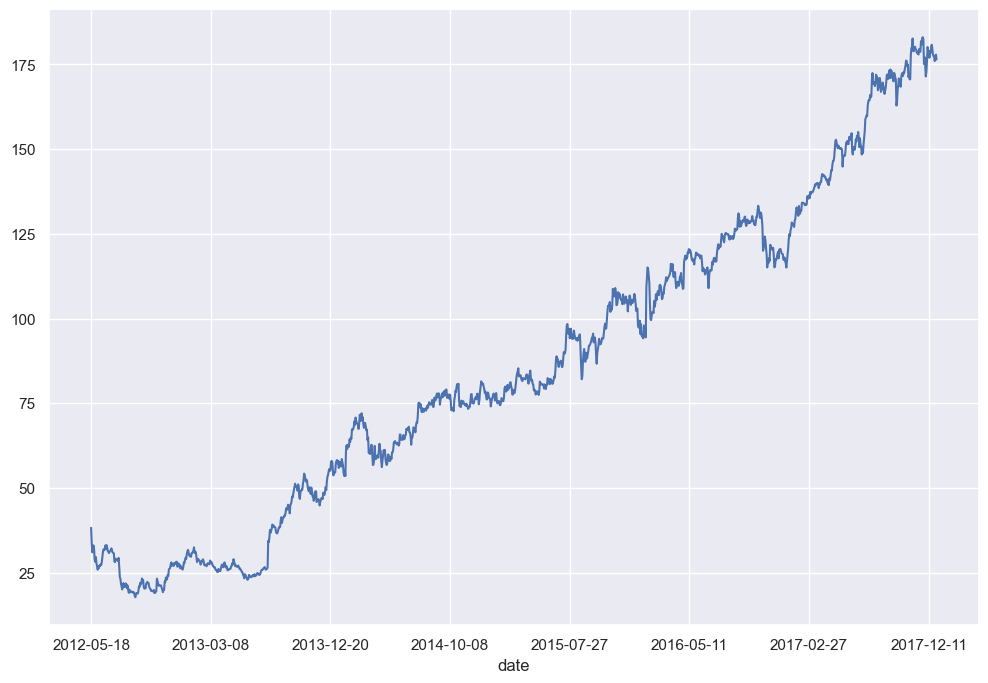

In [19]:
df['price_t'].plot(figsize=(12,8))

<Axes: xlabel='date'>

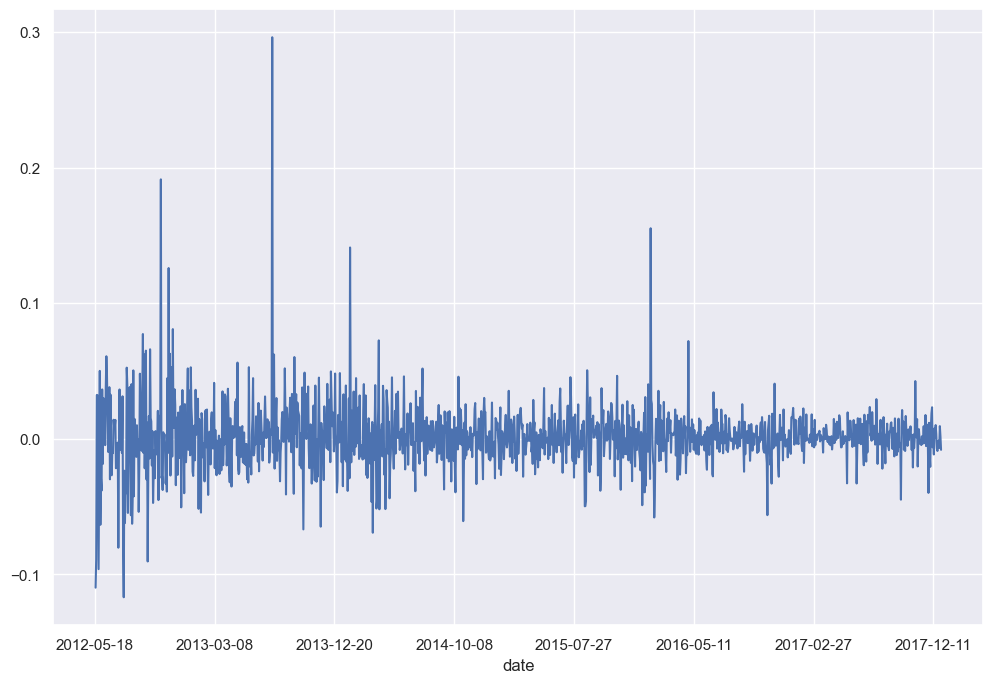

In [22]:
#prices are not predictable because the returns are random
#due to following a random walk
df['returns'].plot(figsize=(12,8))

When we invest in stocks, we base our decisions on
the expected return instead of the realised return.
We base it on what we expect the stock will earn us in the future

There are 3 ways to estimate it:
    -1. using stock's historic average return
    -2. using state-contingent weighted probabilities
    -3. using Asset Pricing Models (ex: CAPM)